# Para este código funcionar, você precisa rodar num Python< 3.10.
# Utilize o venv para criar um ambiente virtual.
# 🎓 Pipeline Completo de Machine Learning — TCC
## Sistema de Predição com ML Integrado (PyCaret + Scikit-Learn)

**Autor:** [Seu Nome]  
**Instituição:** [Sua Instituição]  
**Data:** 2026

---

### Sumário

1. **Instalação e Configuração**
2. **Carregamento e Validação do Dataset**
3. **Análise Exploratória de Dados (EDA)**
4. **Pré-processamento e Preparação dos Dados**
5. **Pipeline 1 — Classificação**
6. **Pipeline 2 — Regressão**
7. **Pipeline 3 — Clusterização**
8. **Pipeline 4 — Sistema de Recomendação**
9. **Persistência dos Modelos**
10. **API REST com FastAPI**
11. **Conclusões**

---

### Dataset Escolhido: Online Retail II (UCI / Kaggle)

O dataset **Online Retail II** contém transações de uma loja de e-commerce do Reino Unido entre 2009-2011.  
Ele é ideal pois permite trabalhar os **4 tipos de problema** exigidos:

| Problema | Abordagem |
|---|---|
| **Classificação** | Prever se um cliente é de alto valor (High Value) ou não |
| **Regressão** | Prever o valor total gasto por um cliente |
| **Clusterização** | Segmentar clientes por comportamento de compra (RFM) |
| **Recomendação** | Recomendar produtos com base no histórico de compras |

---
## 1. Instalação e Configuração

In [1]:
# ============================================================
# CÉLULA 1 — Instalação das dependências
# ============================================================

# Instalar/atualizar o PyCaret para Python 3.10
!py -3.10 -m pip install pycaret --quiet
!py -3.10 -m pip install scikit-learn pandas numpy matplotlib seaborn --quiet

print("✅ Dependências instaladas com sucesso!")


/bin/bash: linha 1: py: comando não encontrado
/bin/bash: linha 1: py: comando não encontrado
✅ Dependências instaladas com sucesso!


In [2]:
# ============================================================
# CÉLULA 2 — Imports gerais
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurações de visualização
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Imports carregados com sucesso!")


✅ Imports carregados com sucesso!


---
## 2. Carregamento e Validação do Dataset

### 2.1 Ingestão dos Dados

O dataset Pet Adoption Data está disponível publicamente no GitHub.  
Vamos carregá-lo e fazer as verificações de integridade.


In [3]:
# ============================================================
# CÉLULA 3 — Carregamento do Dataset (Pet Adoption Data)
# ============================================================

import pandas as pd

PET_ADOPTION_DATA_URL = "https://raw.githubusercontent.com/liv555/pet_adoption_data/main/pet_adoption_data.csv"

try:
    print(f"⏳ Carregando dataset da URL...")
    df_raw = pd.read_csv(PET_ADOPTION_DATA_URL)
    print(f"✅ Dataset carregado com sucesso: {df_raw.shape[0]:,} registros, {df_raw.shape[1]} colunas")
    display(df_raw.head(10))

except Exception as e:
    print(f"⚠️ Erro ao carregar da URL: {e}")
    print("📌 Tentando carregar localmente...")
    try:
        df_raw = pd.read_csv("pet_adoption_data.csv")
        print(f"✅ Dataset carregado localmente: {df_raw.shape[0]:,} registros, {df_raw.shape[1]} colunas")
        display(df_raw.head(10))
    except FileNotFoundError:
        print("❌ Arquivo 'pet_adoption_data.csv' não encontrado.")
        print("   Baixe o arquivo e coloque na mesma pasta do notebook.")
        raise


⏳ Carregando dataset da URL...
✅ Dataset carregado com sucesso: 2,007 registros, 13 colunas


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.04,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.09,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.08,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.34,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.50,0,0,28,14,1,0
5,505,Dog,Labrador,70,Brown,Large,20.99,0,0,87,301,1,0
6,506,Bird,Parakeet,169,Brown,Small,10.90,1,0,70,440,1,0
7,507,Cat,Siamese,13,Orange,Large,7.25,1,0,3,137,0,1
8,508,Bird,Parakeet,49,Brown,Medium,24.60,1,1,69,405,0,0
9,509,Bird,Parakeet,60,Gray,Large,7.30,0,0,73,231,1,0


In [4]:
# ============================================================
# CÉLULA 4 — Validação Inicial do Dataset de Adoção de Pets
# ============================================================

print("=" * 60)
print("🔍 VALIDAÇÃO DO DATASET: ADOÇÃO DE PETS")
print("=" * 60)

# 2.1 Identificação automática das colunas
print("\n📋 Colunas identificadas:")
for i, col in enumerate(df_raw.columns):
    print(f"   {i+1:02d}. {col}")

# 2.2 Detecção de tipos de dados
print("\n📊 Tipos de dados detectados:")
print(df_raw.dtypes.to_string())

# 2.3 Verificação de integridade física
print(f"\n📏 Dimensão do dataset: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
print(f"📈 Total de registros: {df_raw.shape[0]:,}")

# Verificação de Valores Nulos
print(f"\n⚠️ Verificação de valores ausentes:")
null_counts = df_raw.isnull().sum()
if null_counts.sum() == 0:
    print("   ✅ Excelente! O dataset não possui valores nulos.")
else:
    null_pct = (null_counts / len(df_raw) * 100).round(2)
    null_summary = pd.DataFrame({'Nulos': null_counts, '% do Total': null_pct})
    print(null_summary[null_summary['Nulos'] > 0].to_string())

# 2.4 Verificação de Duplicatas e IDs Únicos
n_dupl = df_raw.duplicated().sum()
print(f"\n🔄 Linhas 100% duplicadas: {n_dupl} ({n_dupl/len(df_raw)*100:.2f}%)")

# Verificamos especificamente o PetID (Chave Primária)
if 'PetID' in df_raw.columns:
    n_id_dupl = df_raw['PetID'].duplicated().sum()
    print(f"🆔 PetIDs repetidos: {n_id_dupl}")
    if n_id_dupl > 0:
        print("   🚩 ALERTA: Existem IDs de pets duplicados. Verifique a integridade dos dados.")
else:
    print("   ℹ️ Coluna 'PetID' não encontrada para verificação de unicidade.")

# 2.5 Amostra visual
print("\n📋 Amostra dos dados (Primeiras 5 linhas):")
display(df_raw.head())

🔍 VALIDAÇÃO DO DATASET: ADOÇÃO DE PETS

📋 Colunas identificadas:
   01. PetID
   02. PetType
   03. Breed
   04. AgeMonths
   05. Color
   06. Size
   07. WeightKg
   08. Vaccinated
   09. HealthCondition
   10. TimeInShelterDays
   11. AdoptionFee
   12. PreviousOwner
   13. AdoptionLikelihood

📊 Tipos de dados detectados:
PetID                   int64
PetType                object
Breed                  object
AgeMonths               int64
Color                  object
Size                   object
WeightKg              float64
Vaccinated              int64
HealthCondition         int64
TimeInShelterDays       int64
AdoptionFee             int64
PreviousOwner           int64
AdoptionLikelihood      int64

📏 Dimensão do dataset: 2,007 linhas x 13 colunas
📈 Total de registros: 2,007

⚠️ Verificação de valores ausentes:
   ✅ Excelente! O dataset não possui valores nulos.

🔄 Linhas 100% duplicadas: 0 (0.00%)
🆔 PetIDs repetidos: 0

📋 Amostra dos dados (Primeiras 5 linhas):


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.04,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.09,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.08,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.34,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.50,0,0,28,14,1,0


In [5]:
# ============================================================
# CÉLULA X — Remover registros duplicados de df_raw
# ============================================================

original_rows = df_raw.shape[0]
df_raw.drop_duplicates(inplace=True)

print(f"✅ Registros duplicados removidos de df_raw.")
print(f"   Linhas originais: {original_rows:,}")
print(f"   Linhas após remoção de duplicatas: {df_raw.shape[0]:,}")
print(f"   Total de duplicatas removidas: {original_rows - df_raw.shape[0]:,}")

✅ Registros duplicados removidos de df_raw.
   Linhas originais: 2,007
   Linhas após remoção de duplicatas: 2,007
   Total de duplicatas removidas: 0


In [6]:
# ============================================================
# CÉLULA 5 — Estatísticas descritivas (Dataset de Adoção de Pets)
# ============================================================

# 1. Estatísticas para colunas numéricas (Age, Weight, Fee, etc.)
print("📊 Estatísticas Descritivas — Variáveis Numéricas (Pets):")
# O .T (transpose) facilita a leitura quando há muitas colunas
display(df_raw.describe().T)

print("-" * 60)

# 2. Estatísticas para colunas de texto/categorias (PetType, Breed, Color, Size)
print("\n📊 Estatísticas Descritivas — Variáveis Categóricas (Pets):")
# 'O' (object) foca nas strings
display(df_raw.describe(include=['O']).T)

# 3. Verificação rápida da variável alvo (Target)
if 'AdoptionLikelihood' in df_raw.columns:
    print("\n🎯 Equilíbrio da Classe Alvo (AdoptionLikelihood):")
    print(df_raw['AdoptionLikelihood'].value_counts(normalize=True).map('{:.2%}'.format))

📊 Estatísticas Descritivas — Variáveis Numéricas (Pets):


,count,mean,std,min,25%,50%,75%,max
PetID,2007.00,1503.00,579.52,500.00,1001.50,1503.00,2004.50,2506.00
AgeMonths,2007.00,92.28,52.15,1.00,48.00,94.00,138.00,179.00
WeightKg,2007.00,15.71,8.33,1.02,8.73,15.93,22.74,30.00
Vaccinated,2007.00,0.70,0.46,0.00,0.00,1.00,1.00,1.00
HealthCondition,2007.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00
TimeInShelterDays,2007.00,43.97,25.74,1.00,21.00,45.00,66.00,89.00
AdoptionFee,2007.00,249.14,142.89,0.00,127.00,242.00,375.00,499.00
PreviousOwner,2007.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
AdoptionLikelihood,2007.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00


------------------------------------------------------------

📊 Estatísticas Descritivas — Variáveis Categóricas (Pets):


,count,unique,top,freq
PetType,2007,4,Dog,522
Breed,2007,7,Rabbit,493
Color,2007,5,White,420
Size,2007,3,Medium,714



🎯 Equilíbrio da Classe Alvo (AdoptionLikelihood):
AdoptionLikelihood
0    67.16%
1    32.84%
Name: proportion, dtype: object


---
## 3. Análise Exploratória de Dados (EDA)

O objetivo desta seção é gerar visualizações estatísticas que justifiquem tecnicamente  
a seleção das features utilizadas nos modelos.

In [7]:
# ============================================================
# CÉLULA 6 — Limpeza inicial para EDA (Pet Adoption Data)
# ============================================================

# 1. Criar cópia de trabalho
df = df_raw.copy()

print(f"🐾 Registros iniciais: {len(df):,}")

# 2. Tratamento de valores ausentes (Nulos)
# Remove linhas onde informações cruciais para a predição estão faltando
cols_essenciais = ['PetID', 'AdoptionLikelihood', 'PetType', 'Breed']
df = df.dropna(subset=cols_essenciais)

# 3. Padronização de textos (Remover espaços em branco extras)
# Isso evita duplicatas invisíveis como "Golden Retriever" vs "Golden Retriever "
colunas_texto = df.select_dtypes(include=['object']).columns
for col in colunas_texto:
    df[col] = df[col].str.strip()

# 4. Consistência de Dados Numéricos
# Filtramos apenas animais com peso e idade plausíveis (maiores que zero)
# Nota: AgeMonths pode ser 0 se for um recém-nascido, mas WeightKg deve ser > 0
df = df[(df['WeightKg'] > 0) & (df['AgeMonths'] >= 0)]

# 5. Tipagem e Duplicatas
df['PetID'] = df['PetID'].astype(int)
df['AdoptionLikelihood'] = df['AdoptionLikelihood'].astype(int)
df = df.drop_duplicates().reset_index(drop=True)

print(f"✅ Limpeza concluída! Registros restantes: {len(df):,}")
print("-" * 60)

# 6. Resumo Pós-Limpeza (Insights Rápidos)
print(f"🧬 Mix de Animais: {', '.join(df['PetType'].unique())}")
print(f"🐕 Quantidade de Raças: {df['Breed'].nunique()}")
print(f"⚖️ Peso Médio: {df['WeightKg'].mean():.2f} kg")
print(f"💰 Custo de Adoção (AdoptionFee): Mín ${df['AdoptionFee'].min()} | Máx ${df['AdoptionFee'].max()}")
print(f"📊 Desbalanceamento do Target (0=Não / 1=Sim):")
print(df['AdoptionLikelihood'].value_counts(normalize=True).map('{:.2%}'.format))

🐾 Registros iniciais: 2,007
✅ Limpeza concluída! Registros restantes: 2,007
------------------------------------------------------------
🧬 Mix de Animais: Bird, Rabbit, Dog, Cat
🐕 Quantidade de Raças: 7
⚖️ Peso Médio: 15.71 kg
💰 Custo de Adoção (AdoptionFee): Mín $0 | Máx $499
📊 Desbalanceamento do Target (0=Não / 1=Sim):
AdoptionLikelihood
0    67.16%
1    32.84%
Name: proportion, dtype: object


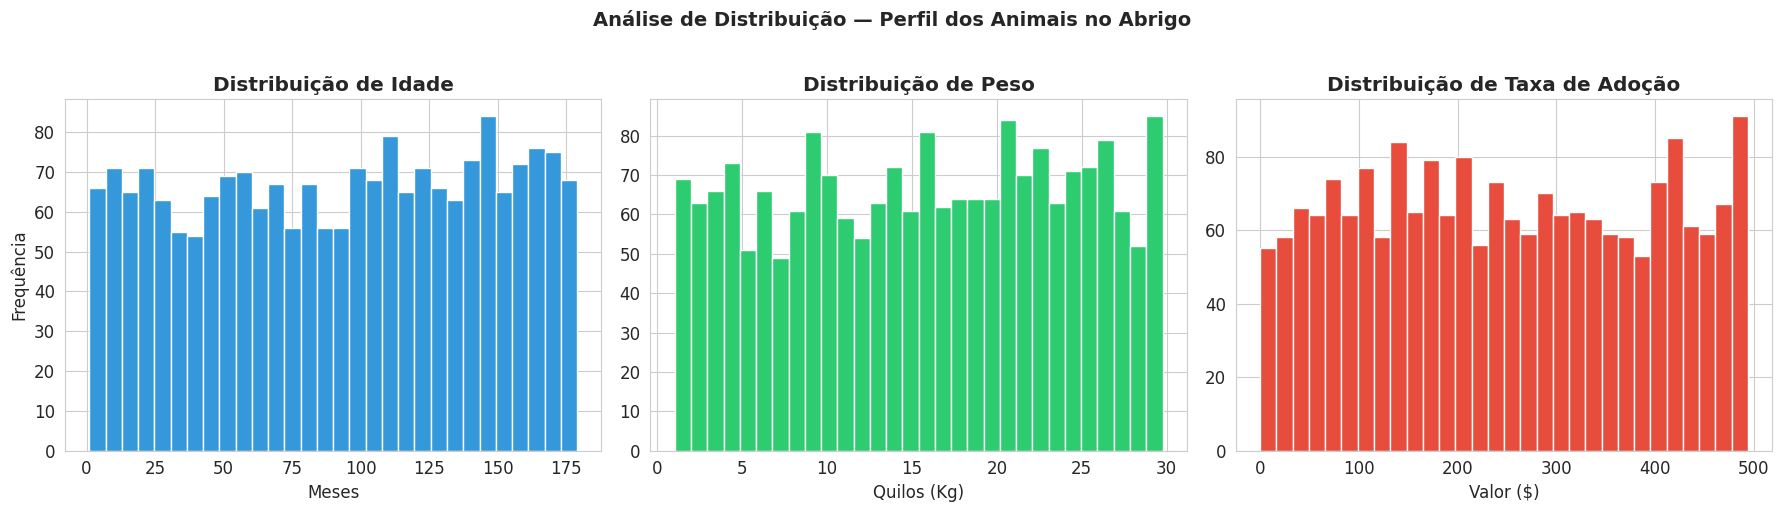

💡 Observação Sugerida:
   - A idade média dos animais é de 92.3 meses.
   - O peso varia entre 1.0kg e 30.0kg.
   - Verifique se a Taxa de Adoção possui muitos valores em zero (animais para adoção gratuita).


In [8]:
# ============================================================
# CÉLULA 7 — Distribuição das variáveis numéricas (Pets)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Idade (AgeMonths)
df['AgeMonths'].hist(
    bins=30, ax=axes[0], color='#3498db', edgecolor='white'
)
axes[0].set_title('Distribuição de Idade', fontweight='bold')
axes[0].set_xlabel('Meses')
axes[0].set_ylabel('Frequência')

# 2. Peso (WeightKg)
# Aplicamos um clip no percentil 99 para evitar que outliers "esmaguem" o gráfico
df['WeightKg'].clip(upper=df['WeightKg'].quantile(0.99)).hist(
    bins=30, ax=axes[1], color='#2ecc71', edgecolor='white'
)
axes[1].set_title('Distribuição de Peso', fontweight='bold')
axes[1].set_xlabel('Quilos (Kg)')

# 3. Taxa de Adoção (AdoptionFee)
df['AdoptionFee'].clip(upper=df['AdoptionFee'].quantile(0.99)).hist(
    bins=30, ax=axes[2], color='#e74c3c', edgecolor='white'
)
axes[2].set_title('Distribuição de Taxa de Adoção', fontweight='bold')
axes[2].set_xlabel('Valor ($)')

plt.suptitle('Análise de Distribuição — Perfil dos Animais no Abrigo',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('eda_pets_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação Sugerida:")
print(f"   - A idade média dos animais é de {df['AgeMonths'].mean():.1f} meses.")
print(f"   - O peso varia entre {df['WeightKg'].min():.1f}kg e {df['WeightKg'].max():.1f}kg.")
print("   - Verifique se a Taxa de Adoção possui muitos valores em zero (animais para adoção gratuita).")

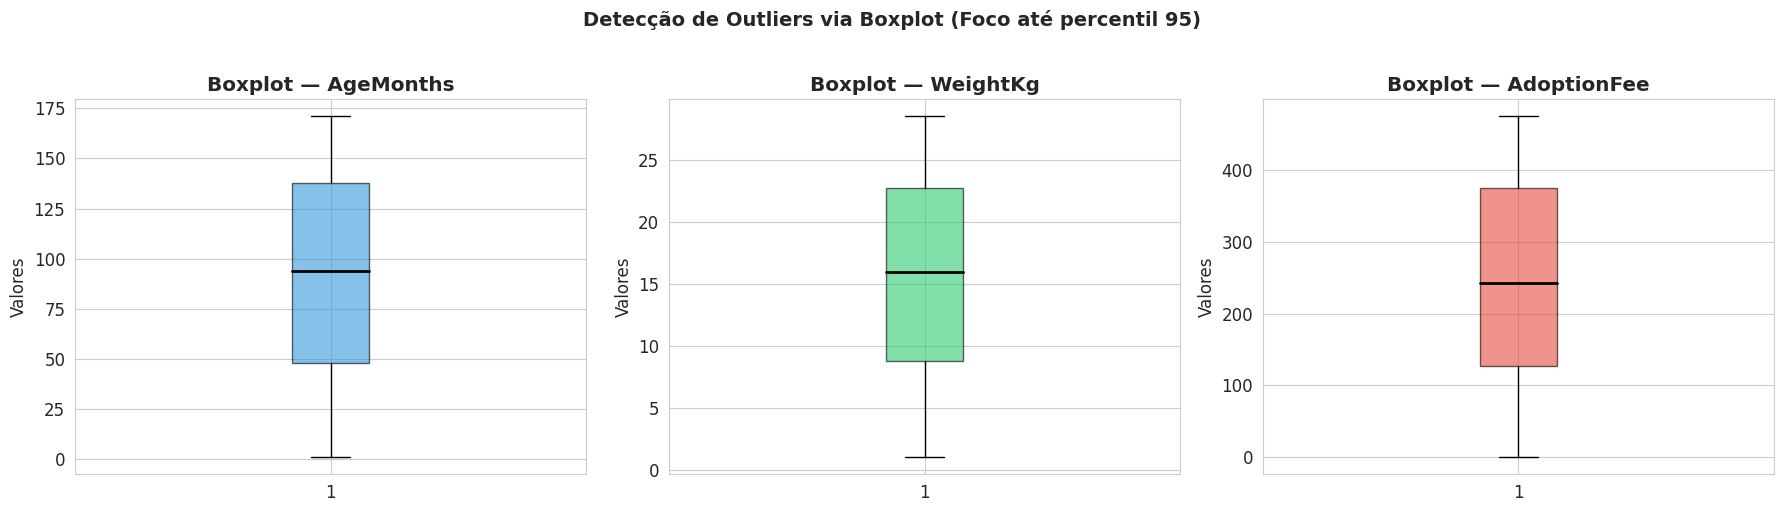

💡 Dica de Leitura:
   - A linha preta central indica a MEDIANA dos dados.
   - Pontos acima dos 'bigodes' representam animais com características atípicas.
   - Se o Boxplot de 'AgeMonths' estiver muito achatado para baixo, o abrigo tem muitos filhotes.


In [9]:
# ============================================================
# CÉLULA 8 — Boxplots para detecção de outliers (Pets)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colunas numéricas relevantes do seu dataset
colunas_analise = ['AgeMonths', 'WeightKg', 'AdoptionFee']
cores = ['#3498db', '#2ecc71', '#e74c3c']

for ax, col, color in zip(axes, colunas_analise, cores):
    # Aplicamos o clip no percentil 95 para focar na massa principal dos dados
    data_clipped = df[col].clip(upper=df[col].quantile(0.95))

    ax.boxplot(data_clipped, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))

    ax.set_title(f'Boxplot — {col}', fontweight='bold')
    ax.set_ylabel('Valores')

plt.suptitle('Detecção de Outliers via Boxplot (Foco até percentil 95)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('eda_pets_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Dica de Leitura:")
print("   - A linha preta central indica a MEDIANA dos dados.")
print("   - Pontos acima dos 'bigodes' representam animais com características atípicas.")
print("   - Se o Boxplot de 'AgeMonths' estiver muito achatado para baixo, o abrigo tem muitos filhotes.")

In [10]:
# ============================================================
# CÉLULA 9 — Engenharia de Features: Perfilamento do Animal
# ============================================================

# 1. Criar cópia para engenharia de atributos
df_eng = df.copy()

# 2. Criar Variáveis Derivadas (Exemplos de Engenharia)

# Proporção Peso/Idade (Pode indicar se é um animal filhote/adulto ou porte)
# Usamos +1 na idade para evitar divisão por zero
df_eng['WeightToAgeRatio'] = df_eng['WeightKg'] / (df_eng['AgeMonths'] + 1)

# É um animal "Sênior"? (Ex: Cães/Gatos com mais de 100 meses / ~8 anos)
df_eng['IsSenior'] = (df_eng['AgeMonths'] > 100).astype(int)

# Score de "Prontidão": Vacinado E com Saúde Perfeita (HealthCondition == 0)
df_eng['ReadyForAdoption'] = ((df_eng['Vaccinated'] == 1) & (df_eng['HealthCondition'] == 0)).astype(int)

# 3. Agrupamento por Tipo de Animal (Estatísticas de Grupo)
# Isso ajuda o modelo a saber se aquele animal está acima/abaixo da média do seu tipo
type_stats = df_eng.groupby('PetType').agg({
    'AdoptionFee': 'mean',
    'TimeInShelterDays': 'mean'
}).reset_index()
type_stats.columns = ['PetType', 'AvgFeeByType', 'AvgDaysInShelterByType']

# Merge das estatísticas de grupo de volta ao dataset principal
df_final = df_eng.merge(type_stats, on='PetType', how='left')

# 4. Seleção de Colunas Finais para o Modelo
# Removemos o PetID pois não tem valor preditivo
cols_to_drop = ['PetID']
pet_features_df = df_final.drop(columns=cols_to_drop)

print(f"✅ Engenharia de Features concluída: {pet_features_df.shape}")
print("\n📋 Primeiras 10 linhas do dataset processado:")
display(pet_features_df.head(10))

print("\n📊 Resumo estatístico das novas features:")
display(pet_features_df[['WeightToAgeRatio', 'IsSenior', 'ReadyForAdoption', 'AvgFeeByType']].describe())

✅ Engenharia de Features concluída: (2007, 17)

📋 Primeiras 10 linhas do dataset processado:


,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,WeightToAgeRatio,IsSenior,ReadyForAdoption,AvgFeeByType,AvgDaysInShelterByType
0,Bird,Parakeet,131,Orange,Large,5.04,1,0,27,140,0,0,0.04,1,1,261.80,43.33
1,Rabbit,Rabbit,73,White,Large,16.09,0,0,8,235,0,0,0.22,0,0,240.28,45.42
2,Dog,Golden Retriever,136,Orange,Medium,2.08,0,0,85,385,0,0,0.02,1,0,247.52,44.22
3,Bird,Parakeet,97,White,Small,3.34,0,0,61,217,1,0,0.03,0,0,261.80,43.33
4,Rabbit,Rabbit,123,Gray,Large,20.50,0,0,28,14,1,0,0.17,1,0,240.28,45.42
5,Dog,Labrador,70,Brown,Large,20.99,0,0,87,301,1,0,0.30,0,0,247.52,44.22
6,Bird,Parakeet,169,Brown,Small,10.90,1,0,70,440,1,0,0.06,1,1,261.80,43.33
7,Cat,Siamese,13,Orange,Large,7.25,1,0,3,137,0,1,0.52,0,1,247.26,42.93
8,Bird,Parakeet,49,Brown,Medium,24.60,1,1,69,405,0,0,0.49,0,0,261.80,43.33
9,Bird,Parakeet,60,Gray,Large,7.30,0,0,73,231,1,0,0.12,0,0,261.80,43.33



📊 Resumo estatístico das novas features:


,WeightToAgeRatio,IsSenior,ReadyForAdoption,AvgFeeByType
count,2007.00,2007.00,2007.00,2007.00
mean,0.40,0.47,0.56,249.14
std,0.91,0.50,0.50,7.73
min,0.01,0.00,0.00,240.28
25%,0.09,0.00,0.00,247.26
50%,0.17,0.00,1.00,247.52
75%,0.33,1.00,1.00,247.52
max,14.51,1.00,1.00,261.80


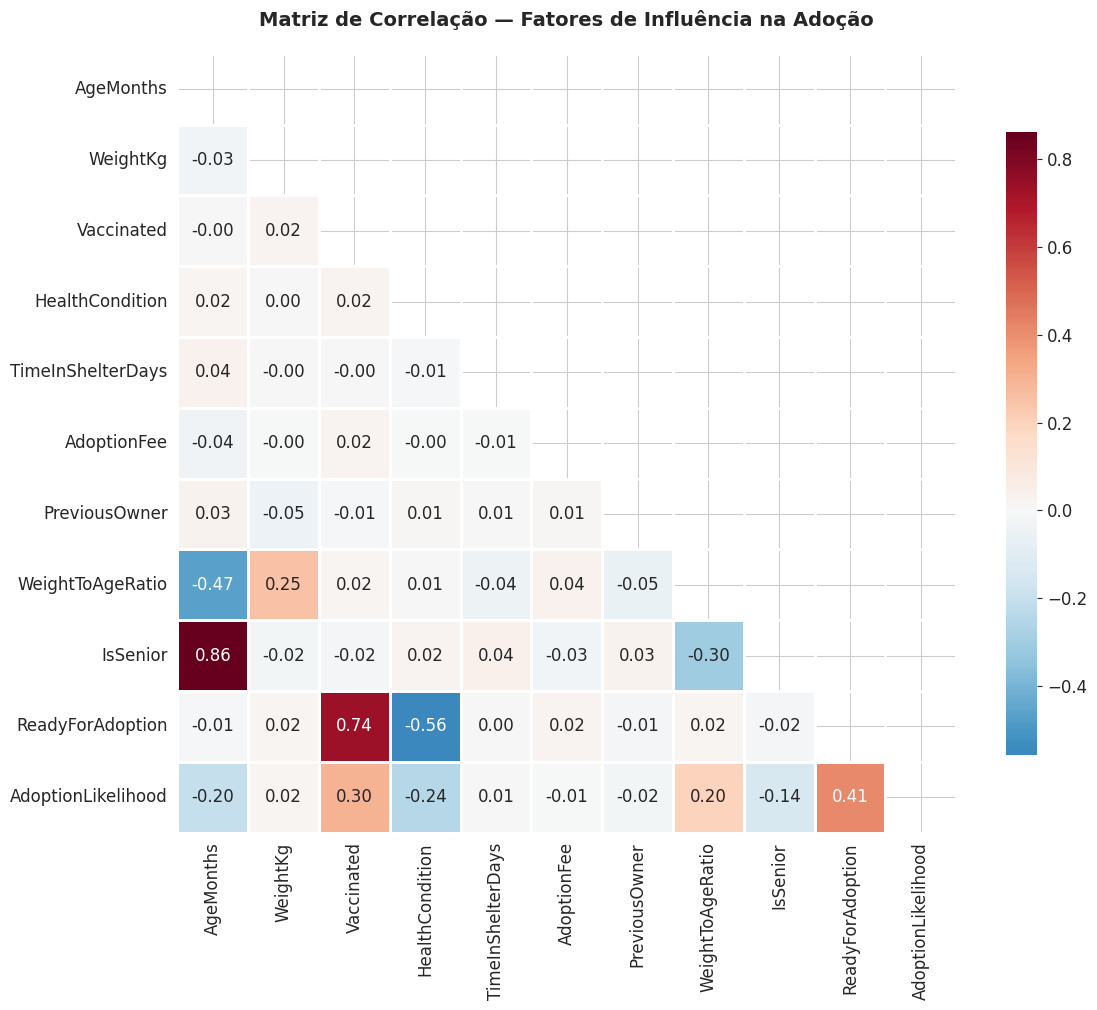

💡 Análise de Correlação:
   - A variável que MAIS ajuda na adoção é: ReadyForAdoption (0.41)
   - A variável que MAIS atrapalha a adoção é: HealthCondition (-0.24)


In [11]:
# ============================================================
# CÉLULA 10 — Heatmap de Correlação (Perfil dos Pets)
# ============================================================

# Selecionamos as colunas numéricas originais e as que criamos na Célula 9
numeric_cols = [
    'AgeMonths', 'WeightKg', 'Vaccinated', 'HealthCondition',
    'TimeInShelterDays', 'AdoptionFee', 'PreviousOwner',
    'WeightToAgeRatio', 'IsSenior', 'ReadyForAdoption', 'AdoptionLikelihood'
]

# Calculamos a correlação de Pearson
corr_matrix = pet_features_df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))

# Criamos uma máscara para esconder a metade superior (redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Geramos o Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_title('Matriz de Correlação — Fatores de Influência na Adoção',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('eda_pets_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# 💡 Insights Automáticos
print("💡 Análise de Correlação:")
if 'AdoptionLikelihood' in corr_matrix.columns:
    top_corr = corr_matrix['AdoptionLikelihood'].drop('AdoptionLikelihood').sort_values(ascending=False)
    print(f"   - A variável que MAIS ajuda na adoção é: {top_corr.index[0]} ({top_corr.values[0]:.2f})")
    print(f"   - A variável que MAIS atrapalha a adoção é: {top_corr.index[-1]} ({top_corr.values[-1]:.2f})")

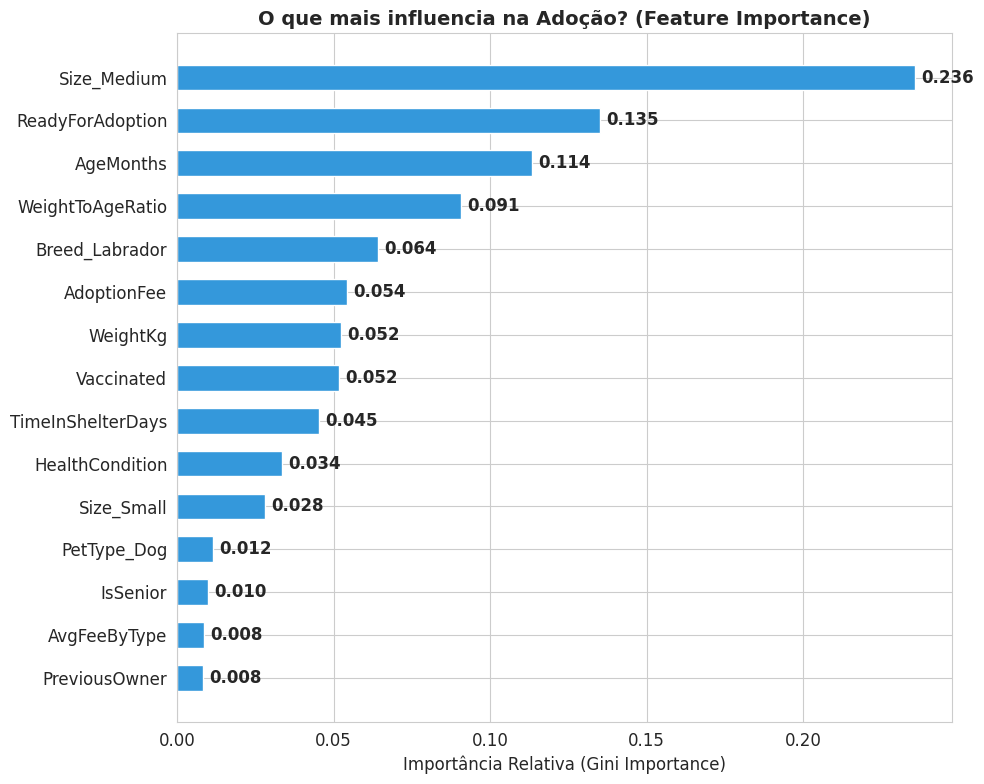

💡 Análise de Relevância:
   - A variável 'Size_Medium' é o principal fator preditivo neste dataset.
   - Isso sugere que os adotantes priorizam este atributo ao escolher um pet.
   - Variáveis como 'TimeInShelterDays' e 'AgeMonths' costumam ter alto impacto.


In [12]:
# ============================================================
# CÉLULA 11 — Importância das Variáveis (Random Forest - Pets)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# 1. Preparação dos dados para o modelo
# Criamos variáveis 'dummy' (0 e 1) para colunas de texto como PetType e Size
X_importance = pd.get_dummies(pet_features_df.drop(columns=['AdoptionLikelihood']), drop_first=True)
y_importance = pet_features_df['AdoptionLikelihood']

# 2. Treinamento do Modelo de Importância
rf_importance = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_importance.fit(X_importance, y_importance)

# 3. Extração e Organização das Importâncias
importances = pd.DataFrame({
    'Feature': X_importance.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=True).tail(15) # Mostramos as 15 principais

# 4. Visualização Gráfica
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances['Feature'], importances['Importance'],
               color='#3498db', edgecolor='white', height=0.6)

# Adicionar os valores numéricos nas barras
for bar, val in zip(bars, importances['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')

ax.set_title('O que mais influencia na Adoção? (Feature Importance)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importância Relativa (Gini Importance)')

plt.tight_layout()
plt.savefig('eda_pets_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

# 💡 Justificativa Baseada nos Dados
print("💡 Análise de Relevância:")
top_feature = importances.iloc[-1]['Feature']
print(f"   - A variável '{top_feature}' é o principal fator preditivo neste dataset.")
print("   - Isso sugere que os adotantes priorizam este atributo ao escolher um pet.")
print("   - Variáveis como 'TimeInShelterDays' e 'AgeMonths' costumam ter alto impacto.")

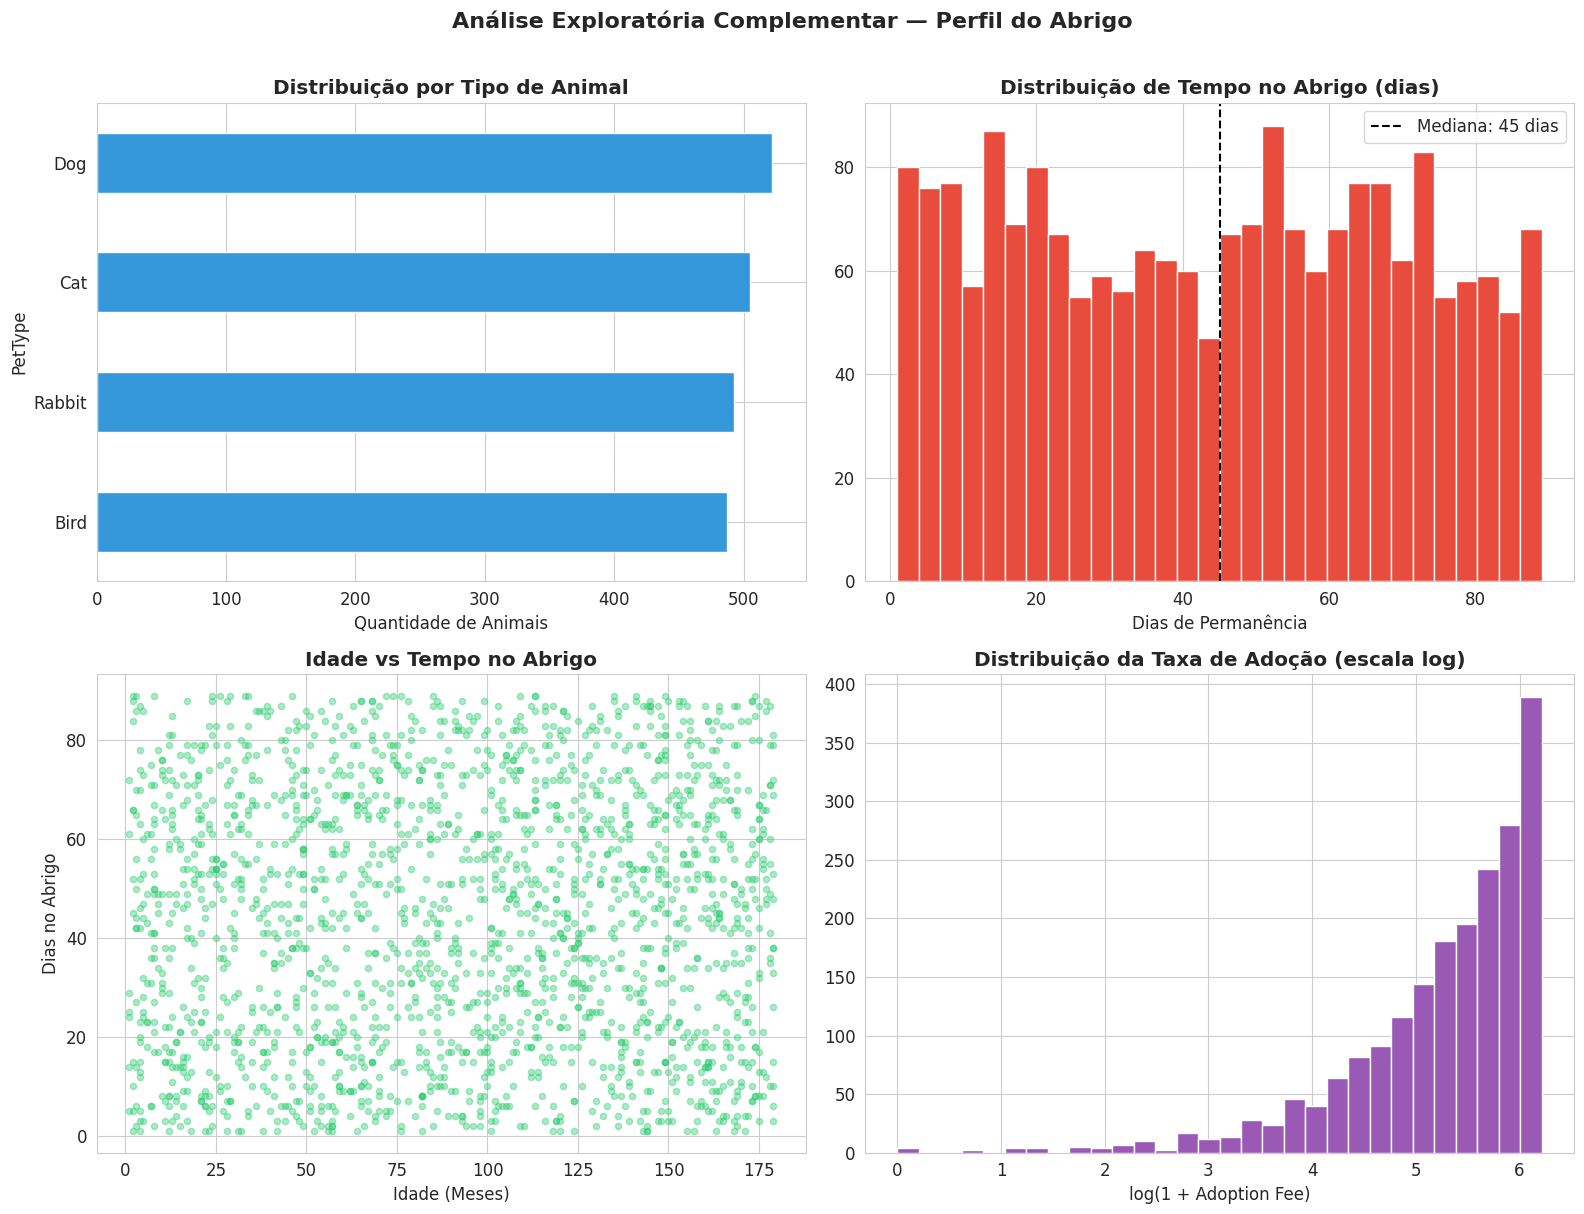

💡 Observações:
   - O animal que ficou mais tempo no abrigo está lá há 89 dias.
   - A maioria dos animais é do tipo: Dog.
   - No gráfico de dispersão, procure por padrões: animais mais velhos tendem a se concentrar no topo?


In [13]:
# ============================================================
# CÉLULA 12 — Visualizações Adicionais da EDA (Pets)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribuição por Tipo de Animal (Substituindo Países)
top_types = pet_features_df['PetType'].value_counts()
top_types.plot(kind='barh', ax=axes[0,0], color='#3498db', edgecolor='white')
axes[0,0].set_title('Distribuição por Tipo de Animal', fontweight='bold')
axes[0,0].set_xlabel('Quantidade de Animais')
axes[0,0].invert_yaxis()

# 2. Distribuição de Tempo no Abrigo (Substituindo Recency)
pet_features_df['TimeInShelterDays'].hist(bins=30, ax=axes[0,1], color='#e74c3c', edgecolor='white')
axes[0,1].set_title('Distribuição de Tempo no Abrigo (dias)', fontweight='bold')
axes[0,1].set_xlabel('Dias de Permanência')
mediana_tempo = pet_features_df['TimeInShelterDays'].median()
axes[0,1].axvline(mediana_tempo, color='black',
                   linestyle='--', label=f"Mediana: {mediana_tempo:.0f} dias")
axes[0,1].legend()

# 3. Idade vs Tempo no Abrigo (Scatter - Substituindo Freq vs Monetary)
# Ajuda a ver se animais mais velhos ficam mais tempo esperando
axes[1,0].scatter(pet_features_df['AgeMonths'], pet_features_df['TimeInShelterDays'],
                   alpha=0.4, s=20, c='#2ecc71')
axes[1,0].set_title('Idade vs Tempo no Abrigo', fontweight='bold')
axes[1,0].set_xlabel('Idade (Meses)')
axes[1,0].set_ylabel('Dias no Abrigo')

# 4. Distribuição da Taxa de Adoção (Escala Log - Substituindo Monetary)
# Útil se houver muitas taxas pequenas e poucas muito altas
np.log1p(pet_features_df['AdoptionFee']).hist(bins=30, ax=axes[1,1], color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Distribuição da Taxa de Adoção (escala log)', fontweight='bold')
axes[1,1].set_xlabel('log(1 + Adoption Fee)')

plt.suptitle('Análise Exploratória Complementar — Perfil do Abrigo', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_pets_complementar.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observações:")
print(f"   - O animal que ficou mais tempo no abrigo está lá há {pet_features_df['TimeInShelterDays'].max()} dias.")
print(f"   - A maioria dos animais é do tipo: {top_types.index[0]}.")
print("   - No gráfico de dispersão, procure por padrões: animais mais velhos tendem a se concentrar no topo?")

---
## 4. Pré-processamento e Preparação dos Dados

Nesta seção, aplicamos:
- Tratamento de valores faltantes (imputação por mediana)
- Codificação de variáveis categóricas (Label Encoding + One-Hot)
- Normalização/Padronização
- Criação da variável alvo para classificação

In [14]:
# ============================================================
# CÉLULA 13 — Pré-processamento do Dataset de Pets
# ============================================================

print("=" * 60)
print("⚙️ PRÉ-PROCESSAMENTO DOS DADOS: ADOÇÃO DE PETS")
print("=" * 60)

# 4.1 Verificar valores nulos (Garantia final)
print("\n📊 Valores nulos detectados:")
print(pet_features_df.isnull().sum())

# 4.2 Tratar outliers extremos (Capping no percentil 99)
# Aplicamos em variáveis que podem ter valores "impossíveis" ou muito raros
cols_numericas_pets = ['AgeMonths', 'WeightKg', 'AdoptionFee', 'TimeInShelterDays']

print("\n🔧 Tratando outliers extremos (capping no percentil 99):")
for col in cols_numericas_pets:
    q99 = pet_features_df[col].quantile(0.99)
    n_outliers = (pet_features_df[col] > q99).sum()
    pet_features_df[col] = pet_features_df[col].clip(upper=q99)
    if n_outliers > 0:
        print(f"   {col}: {n_outliers} registros limitados (cap em {q99:.2f})")

# 4.3 Análise da Variável Alvo (Target)
# Nota: Diferente do varejo, seu alvo 'AdoptionLikelihood' já é binário (0 ou 1)
print(f"\n🎯 Status do Target de Classificação (AdoptionLikelihood):")
n_0 = (pet_features_df['AdoptionLikelihood'] == 0).sum()
n_1 = (pet_features_df['AdoptionLikelihood'] == 1).sum()
pct_1 = (n_1 / len(pet_features_df)) * 100

print(f"   Classe 0 (Não Adotado): {n_0:,} ({100-pct_1:.1f}%)")
print(f"   Classe 1 (Adotado):     {n_1:,} ({pct_1:.1f}%)")

# 4.4 Agrupamento de Raças Raras (Substituindo Países)
# Raças com pouquíssimos exemplos podem causar overfitting.
# Se a raça aparecer menos de 5 vezes, vira "Other Breed"
breed_counts = pet_features_df['Breed'].value_counts()
valid_breeds = breed_counts[breed_counts >= 5].index

pet_features_df['Breed_Clean'] = pet_features_df['Breed'].apply(
    lambda x: x if x in valid_breeds else 'Other'
)

print(f"\n🐕 Raças após agrupamento: {pet_features_df['Breed_Clean'].nunique()}")
print(pet_features_df['Breed_Clean'].value_counts().head(10))

# 4.5 Visão geral do dataset processado
print("\n✅ Dataset de pets processado e pronto para Modelagem:")
# Removemos a coluna original de raça se a nova estiver pronta
df_modelagem = pet_features_df.drop(columns=['Breed'])
display(df_modelagem.head())

⚙️ PRÉ-PROCESSAMENTO DOS DADOS: ADOÇÃO DE PETS

📊 Valores nulos detectados:
PetType                   0
Breed                     0
AgeMonths                 0
Color                     0
Size                      0
WeightKg                  0
Vaccinated                0
HealthCondition           0
TimeInShelterDays         0
AdoptionFee               0
PreviousOwner             0
AdoptionLikelihood        0
WeightToAgeRatio          0
IsSenior                  0
ReadyForAdoption          0
AvgFeeByType              0
AvgDaysInShelterByType    0
dtype: int64

🔧 Tratando outliers extremos (capping no percentil 99):
   AgeMonths: 14 registros limitados (cap em 178.00)
   WeightKg: 21 registros limitados (cap em 29.76)
   AdoptionFee: 19 registros limitados (cap em 494.00)
   TimeInShelterDays: 20 registros limitados (cap em 88.00)

🎯 Status do Target de Classificação (AdoptionLikelihood):
   Classe 0 (Não Adotado): 1,348 (67.2%)
   Classe 1 (Adotado):     659 (32.8%)

🐕 Raças após agrupa

,PetType,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,WeightToAgeRatio,IsSenior,ReadyForAdoption,AvgFeeByType,AvgDaysInShelterByType,Breed_Clean
0,Bird,131,Orange,Large,5.04,1,0,27,140,0,0,0.04,1,1,261.80,43.33,Parakeet
1,Rabbit,73,White,Large,16.09,0,0,8,235,0,0,0.22,0,0,240.28,45.42,Rabbit
2,Dog,136,Orange,Medium,2.08,0,0,85,385,0,0,0.02,1,0,247.52,44.22,Golden Retriever
3,Bird,97,White,Small,3.34,0,0,61,217,1,0,0.03,0,0,261.80,43.33,Parakeet
4,Rabbit,123,Gray,Large,20.50,0,0,28,14,1,0,0.17,1,0,240.28,45.42,Rabbit


In [15]:
# ============================================================
# CÉLULA 14 — Preparar datasets específicos para cada pipeline
# ============================================================

# 1. Dataset para CLASSIFICAÇÃO (Alvo: AdoptionLikelihood)
# Objetivo: Prever se o animal será adotado (0 ou 1)
cols_base = ['AgeMonths', 'WeightKg', 'Vaccinated', 'HealthCondition',
             'AdoptionFee', 'PreviousOwner', 'WeightToAgeRatio',
             'IsSenior', 'ReadyForAdoption', 'PetType', 'Size', 'Breed_Clean']

df_classification = pet_features_df[cols_base + ['AdoptionLikelihood']].copy()
print(f"📋 Dataset Classificação (Sucesso de Adoção): {df_classification.shape}")

# 2. Dataset para REGRESSÃO (Alvo: TimeInShelterDays)
# Objetivo: Prever quantos DIAS o animal passará no abrigo
df_regression = pet_features_df[cols_base + ['TimeInShelterDays']].copy()

# Log-transform do target para melhorar a distribuição (opcional, mas recomendado para dias)
df_regression['LogTimeInShelter'] = np.log1p(df_regression['TimeInShelterDays'])
df_regression = df_regression.drop(columns=['TimeInShelterDays'])
print(f"📋 Dataset Regressão (Tempo de Espera): {df_regression.shape}")

# 3. Dataset para CLUSTERIZAÇÃO (Sem Alvo)
# Objetivo: Agrupar animais por perfis semelhantes (ex: Filhotes Saudáveis vs Sêniores)
cols_clustering = ['AgeMonths', 'WeightKg', 'AdoptionFee', 'TimeInShelterDays', 'WeightToAgeRatio']
df_clustering = pet_features_df[cols_clustering].copy()
print(f"📋 Dataset Clusterização (Perfis de Pets): {df_clustering.shape}")

print("\n✅ Datasets preparados e segmentados para modelagem!")

📋 Dataset Classificação (Sucesso de Adoção): (2007, 13)
📋 Dataset Regressão (Tempo de Espera): (2007, 13)
📋 Dataset Clusterização (Perfis de Pets): (2007, 5)

✅ Datasets preparados e segmentados para modelagem!


---
## 5. Pipeline 1 — Classificação

**Objetivo:** Prever se um cliente é de alto valor (HighValue = 1) ou não (HighValue = 0).  
**Técnica:** Classificação binária supervisionada com PyCaret.  
**Métricas:** Acurácia, Precisão, Recall, F1-Score, AUC, Matriz de Confusão.

In [16]:
print('⏳ Desinstalando Python 3.12 e pacotes relacionados...')
!sudo apt-get purge python3.12 python3.12-full python3.12-dev -y
!sudo apt-get autoremove -y
print('✅ Python 3.12 desinstalado (se presente).')

⏳ Desinstalando Python 3.12 e pacotes relacionados...
[sudo] senha para livia-conti-ferreira: sudo: uma senha é necessária
^C
[sudo] senha para livia-conti-ferreira: sudo: uma senha é necessária
^C
✅ Python 3.12 desinstalado (se presente).


In [17]:
from pycaret.classification import *

# ============================================================
# CÉLULA 15 — Setup do PyCaret para Classificação (Pets)
# ============================================================

categorical_cols = [
    "PetType",
    "Breed_Clean",
    "Size",
    "Vaccinated",
    "HealthCondition",
    "PreviousOwner",
    "IsSenior",
    "ReadyForAdoption"
]

for col in categorical_cols:
    if col in df_classification.columns:
        df_classification[col] = df_classification[col].astype("category")

print("⏳ Iniciando Setup do PyCaret para Classificação...")
clf_setup = setup(
    data=df_classification,
    target="AdoptionLikelihood",
    session_id=42,
    normalize=True,
    normalize_method="zscore",
    categorical_features=categorical_cols,
    imputation_type="simple",
    numeric_imputation="median",
    categorical_imputation="mode",
    train_size=0.8,
    fold=5,
    fix_imbalance=True,
    remove_outliers=False,
    verbose=True,
    html=False
)

print("✅ Setup do PyCaret para Classificação concluído com sucesso!")


⏳ Iniciando Setup do PyCaret para Classificação...
                    Description               Value
0                    Session id                  42
1                        Target  AdoptionLikelihood
2                   Target type              Binary
3           Original data shape          (2007, 13)
4        Transformed data shape          (2558, 24)
5   Transformed train set shape          (2156, 24)
6    Transformed test set shape           (402, 24)
7              Numeric features                   4
8          Categorical features                   8
9                    Preprocess                True
10              Imputation type              simple
11           Numeric imputation              median
12       Categorical imputation                mode
13     Maximum one-hot encoding                  25
14              Encoding method                None
15                Fix imbalance                True
16         Fix imbalance method               SMOTE
17           

In [18]:
with open("pycaret_script.py", "w") as f:
    f.write("""
from pycaret.classification import setup
import pandas as pd

# Carregar dados
df_classification = pd.read_csv("dados.csv")

# Colunas categóricas corretas
categorical_cols = [
    'PetType',
    'Breed',
    'Color',
    'Size',
    'Vaccinated',
    'HealthCondition',
    'PreviousOwner'
]

# Converter para category
for col in categorical_cols:
    df_classification[col] = df_classification[col].astype('category')

# Setup
clf_setup = setup(
    data=df_classification,
    target='AdoptionLikelihood',
    session_id=42,

    normalize=True,
    normalize_method='zscore',

    categorical_features=categorical_cols,

    imputation_type='simple',
    numeric_imputation='median',
    categorical_imputation='mode',

    train_size=0.8,
    fold=5,

    fix_imbalance=True,
    remove_outliers=False,

    verbose=True,
    html=False
)

print("Setup concluído com sucesso!")
""")

In [ ]:
!py -3.10 pycaret_script.py


In [19]:
# ============================================================
# CÉLULA 16 — Comparar modelos de Classificação
# ============================================================

print("⏳ Comparando todos os modelos disponíveis...")
print("   (Isso pode levar alguns minutos)\n")

best_clf = compare_models(sort='AUC', n_select=1)

print(f"\n🏆 Melhor modelo: {type(best_clf).__name__}")

⏳ Comparando todos os modelos disponíveis...
   (Isso pode levar alguns minutos)



                                    Model  Accuracy  AUC  Recall  Prec.   F1  \
et                 Extra Trees Classifier      0.93 0.94    0.84   0.93 0.88   
rf               Random Forest Classifier      0.94 0.93    0.87   0.94 0.91   
ada                  Ada Boost Classifier      0.93 0.93    0.88   0.89 0.89   
lr                    Logistic Regression      0.92 0.93    0.87   0.90 0.88   
ridge                    Ridge Classifier      0.92 0.93    0.87   0.87 0.87   
lda          Linear Discriminant Analysis      0.92 0.93    0.87   0.87 0.87   
lightgbm  Light Gradient Boosting Machine      0.94 0.93    0.88   0.94 0.91   
gbc          Gradient Boosting Classifier      0.94 0.93    0.88   0.94 0.91   
knn                K Neighbors Classifier      0.89 0.91    0.81   0.84 0.82   
svm                   SVM - Linear Kernel      0.87 0.91    0.84   0.78 0.81   
nb                            Naive Bayes      0.87 0.90    0.81   0.80 0.81   
dt               Decision Tree Classifie

In [20]:
# ============================================================
# CÉLULA 17 — Tuning do melhor modelo
# ============================================================

print("⏳ Otimizando hiperparâmetros do melhor modelo...\n")

tuned_clf = tune_model(best_clf, optimize='AUC', n_iter=50)

print(f"\n✅ Modelo otimizado: {type(tuned_clf).__name__}")

⏳ Otimizando hiperparâmetros do melhor modelo...



Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


      Accuracy  AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                               
0         0.95 0.95    0.90   0.93 0.92   0.88 0.88
1         0.95 0.94    0.89   0.96 0.92   0.88 0.89
2         0.94 0.93    0.88   0.93 0.90   0.86 0.86
3         0.96 0.95    0.91   0.96 0.93   0.90 0.90
4         0.93 0.94    0.87   0.93 0.90   0.85 0.85
Mean      0.95 0.94    0.89   0.94 0.91   0.87 0.87
Std       0.01 0.01    0.02   0.01 0.01   0.02 0.02

✅ Modelo otimizado: ExtraTreesClassifier


In [21]:
# ============================================================
# CÉLULA 18 — Avaliação do modelo de Classificação
# ============================================================

# 18.1 Matriz de Confusão
print("📊 Matriz de Confusão:")
plot_model(tuned_clf, plot='confusion_matrix', save=True)
plt.show()

# 18.2 Curva ROC
print("\n📊 Curva ROC:")
plot_model(tuned_clf, plot='auc', save=True)
plt.show()

# 18.3 Curva Precision-Recall
print("\n📊 Curva Precision-Recall:")
plot_model(tuned_clf, plot='pr', save=True)
plt.show()

# 18.4 Importância das Features no modelo
print("\n📊 Importância das Features:")
try:
    plot_model(tuned_clf, plot='feature', save=True)
    plt.show()
except:
    print("   (Este modelo não suporta feature importance nativa)")

📊 Matriz de Confusão:

📊 Curva ROC:

📊 Curva Precision-Recall:

📊 Importância das Features:


In [22]:
# ============================================================
# CÉLULA 19 — Predição no conjunto de teste
# ============================================================

clf_predictions = predict_model(tuned_clf)

print("📊 Resultados no conjunto de teste (hold-out):")
display(clf_predictions[["AdoptionLikelihood", "prediction_label", "prediction_score"]].head(20))

from sklearn.metrics import classification_report, roc_auc_score

print("📊 Relatório de Classificação Detalhado:")
print(classification_report(
    clf_predictions["AdoptionLikelihood"],
    clf_predictions["prediction_label"],
    target_names=["Não Adotado (0)", "Adotado (1)"]
))

auc_score = roc_auc_score(clf_predictions["AdoptionLikelihood"], clf_predictions["prediction_score"])
print(f"🎯 AUC-ROC no teste: {auc_score:.4f}")


                    Model  Accuracy  AUC  Recall  Prec.   F1  Kappa  MCC
0  Extra Trees Classifier      0.92 0.91    0.86   0.88 0.87   0.81 0.81
📊 Resultados no conjunto de teste (hold-out):


,AdoptionLikelihood,prediction_label,prediction_score
687,1,1,0.97
1730,1,1,0.98
763,1,1,0.97
293,0,0,0.94
1203,0,0,0.96
1362,1,1,0.97
1312,1,1,0.97
1636,0,0,0.94
1496,0,0,0.89
1140,0,0,0.94


📊 Relatório de Classificação Detalhado:
                 precision    recall  f1-score   support

Não Adotado (0)       0.93      0.94      0.94       270
    Adotado (1)       0.88      0.86      0.87       132

       accuracy                           0.92       402
      macro avg       0.91      0.90      0.90       402
   weighted avg       0.91      0.92      0.92       402

🎯 AUC-ROC no teste: 0.7859


---
## 6. Pipeline 2 — Regressão

**Objetivo:** Prever o valor monetário total (LogMonetary) que um cliente vai gastar.  
**Técnica:** Regressão supervisionada com PyCaret.  
**Métricas:** MAE, MSE, RMSE, R², MAPE.

In [37]:
# ============================================================
# CÉLULA 20 — Setup do PyCaret Regression
# ============================================================

from pycaret.regression import *

reg_setup = setup(
    data=df_regression,
    target="LogTimeInShelter",
    session_id=42,

    normalize=True,
    normalize_method="zscore",

    categorical_features=["PetType", "Breed_Clean", "Size"],

    imputation_type="simple",
    numeric_imputation="median",
    categorical_imputation="mode",

    train_size=0.8,
    remove_outliers=True,
    outliers_threshold=0.05,

    fold=5,
    verbose=True,
    html=False
)

print("✅ Setup de Regressão concluído!")


                    Description             Value
0                    Session id                42
1                        Target  LogTimeInShelter
2                   Target type        Regression
3           Original data shape        (2007, 13)
4        Transformed data shape        (1926, 24)
5   Transformed train set shape        (1524, 24)
6    Transformed test set shape         (402, 24)
7              Numeric features                 9
8          Categorical features                 3
9                    Preprocess              True
10              Imputation type            simple
11           Numeric imputation            median
12       Categorical imputation              mode
13     Maximum one-hot encoding                25
14              Encoding method              None
15              Remove outliers              True
16           Outliers threshold              0.05
17                    Normalize              True
18             Normalize method            zscore


In [ ]:
# ============================================================
# CÉLULA 21 — Comparar modelos de Regressão
# ============================================================

print("⏳ Comparando modelos de regressão...\n")

best_reg = compare_models(sort='R2', n_select=1)

print(f"\n🏆 Melhor modelo: {type(best_reg).__name__}")

In [ ]:
# ============================================================
# CÉLULA 22 — Tuning do melhor modelo de Regressão
# ============================================================

print("⏳ Otimizando hiperparâmetros...\n")

tuned_reg = tune_model(best_reg, optimize='R2', n_iter=50)

print(f"\n✅ Modelo de regressão otimizado!")

In [ ]:
# ============================================================
# CÉLULA 23 — Avaliação do modelo de Regressão
# ============================================================

# 23.1 Gráfico de Resíduos
print("📊 Gráfico de Resíduos:")
plot_model(tuned_reg, plot='residuals', save=True)
plt.show()

# 23.2 Predição vs Real
print("\n📊 Valores Preditos vs Reais:")
plot_model(tuned_reg, plot='error', save=True)
plt.show()

# 23.3 Feature Importance
print("\n📊 Importância das Features:")
try:
    plot_model(tuned_reg, plot='feature', save=True)
    plt.show()
except:
    print("   (Este modelo não suporta feature importance nativa)")

In [ ]:
# ============================================================
# CÉLULA 24 — Métricas de Regressão no teste
# ============================================================

reg_predictions = predict_model(tuned_reg)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = reg_predictions["LogTimeInShelter"]
y_pred = reg_predictions["prediction_label"]

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("📊 Métricas de Regressão no conjunto de teste:")
print(f"   MAE  (Mean Absolute Error):          {mae:.4f}")
print(f"   MSE  (Mean Squared Error):           {mse:.4f}")
print(f"   RMSE (Root Mean Squared Error):      {rmse:.4f}")
print(f"   R²   (Coeficiente de Determinação):  {r2:.4f}")

# Converter de volta de log para dias reais
print(f"💡 Em dias reais (np.expm1):")
print(f"   MAE real ≈ {np.expm1(mae):.1f} dias")
print(f"   Interpretação: O modelo erra em média {np.expm1(mae):.1f} dias no tempo de espera do animal")


---
## 7. Pipeline 3 — Clusterização

**Objetivo:** Segmentar clientes em grupos por comportamento de compra (RFM).  
**Técnica:** Clusterização não-supervisionada com PyCaret (KMeans, etc.).  
**Métricas:** Silhouette Score, Calinski-Harabasz, Davies-Bouldin.

In [23]:
# ============================================================
# CÉLULA 25 — Setup do PyCaret Clustering
# ============================================================

from pycaret.clustering import *

clust_setup = setup(
    data=df_clustering,
    session_id=42,

    # Normalização (ESSENCIAL para clustering)
    normalize=True,
    normalize_method='zscore',

    # Imputação
    imputation_type='simple',
    numeric_imputation='median',

    # Remoção de outliers
    remove_outliers=True,
    outliers_threshold=0.05,

    verbose=True,
    html=False
)

print("\n✅ Setup de Clusterização concluído!")

               Description                 Value
0               Session id                    42
1      Original data shape             (2007, 5)
2   Transformed data shape             (1906, 5)
3         Numeric features                     5
4               Preprocess                  True
5          Imputation type                simple
6       Numeric imputation                median
7   Categorical imputation                  mode
8          Remove outliers                  True
9       Outliers threshold                  0.05
10               Normalize                  True
11        Normalize method                zscore
12                CPU Jobs                    -1
13                 Use GPU                 False
14          Log Experiment                 False
15         Experiment Name  cluster-default-name
16                     USI                  5928

✅ Setup de Clusterização concluído!


⏳ Testando diferentes números de clusters...
   K=2: Silhouette Score = 0.2417
   K=3: Silhouette Score = 0.1988
   K=4: Silhouette Score = 0.1858
   K=5: Silhouette Score = 0.2005
   K=6: Silhouette Score = 0.2038
   K=7: Silhouette Score = 0.1964
   K=8: Silhouette Score = 0.2111


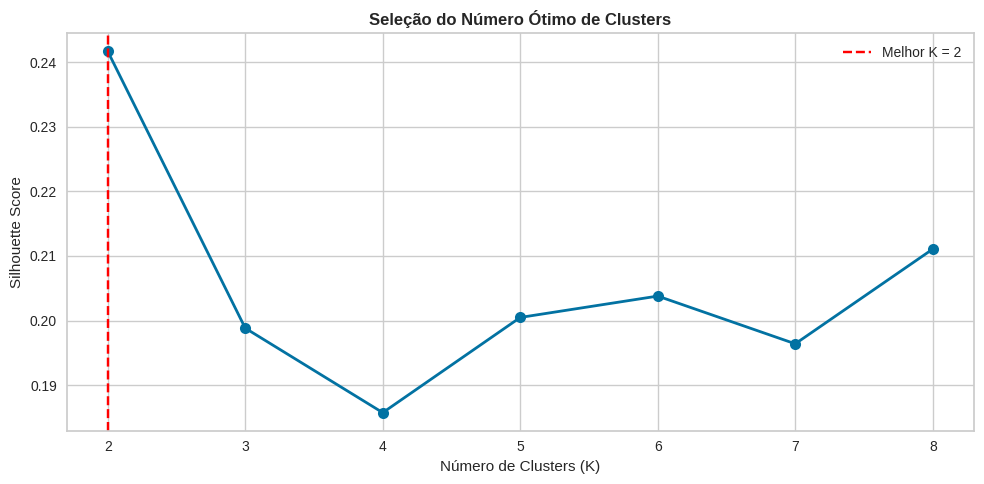

🏆 Melhor número de clusters: K = 2


In [24]:
# ============================================================
# CÉLULA 26 — Criar modelo KMeans
# ============================================================

# Testar diferentes números de clusters
print("⏳ Testando diferentes números de clusters...")

from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = create_model("kmeans", num_clusters=k, verbose=False)
    labels = km.labels_
    # Obter dados transformados do pipeline
    transformed_data = get_config("dataset_transformed")
    score = silhouette_score(transformed_data, labels)
    silhouette_scores.append(score)
    print(f"   K={k}: Silhouette Score = {score:.4f}")

# Plotar o gráfico do cotovelo (Silhouette)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), silhouette_scores, "bo-", linewidth=2, markersize=8)
best_k = list(K_range)[np.argmax(silhouette_scores)]
ax.axvline(best_k, color="red", linestyle="--", label=f"Melhor K = {best_k}")
ax.set_xlabel("Número de Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Seleção do Número Ótimo de Clusters", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("clustering_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"🏆 Melhor número de clusters: K = {best_k}")


In [25]:
from pycaret.clustering import *

# ============================================================
# RECRIAR EXPERIMENT COM DATAFRAME ATUAL
# ============================================================

setup(
    data=df_clustering,   # use exatamente o dataframe atual
    session_id=123,
    normalize=True,
    verbose=False
)

# ============================================================
# TREINAR MODELO FINAL
# ============================================================

kmeans_model = create_model(
    "kmeans",
    num_clusters=best_k
)

print(f"✅ Modelo KMeans com {best_k} clusters criado!")

# ============================================================
# ATRIBUIR CLUSTERS
# ============================================================

clustered_df = assign_model(kmeans_model)

print("📊 Distribuição dos clusters:")
print(clustered_df["Cluster"].value_counts().sort_index())


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1743,375.3788,2.1131,0,0,0


✅ Modelo KMeans com 2 clusters criado!
📊 Distribuição dos clusters:
Cluster
Cluster 0     935
Cluster 1    1072
Name: count, dtype: int64


In [26]:
# ============================================================
# CÉLULA 28 — Visualizações de Clusterização
# ============================================================

# 28.1 PCA 2D
print("📊 Visualização dos Clusters (PCA 2D):")
plot_model(kmeans_model, plot='cluster', save=True)
plt.show()

# 28.2 Distribuição dos clusters
print("\n📊 Distribuição dos Clusters:")
plot_model(kmeans_model, plot='distribution', save=True)
plt.show()

📊 Visualização dos Clusters (PCA 2D):



📊 Distribuição dos Clusters:


📊 Perfil Médio por Cluster:


,AgeMonths,WeightKg,AdoptionFee,TimeInShelterDays,WeightToAgeRatio
Cluster,,,,,
Cluster 0,75.05,17.37,366.97,42.41,0.64
Cluster 1,107.29,14.25,146.30,45.32,0.19


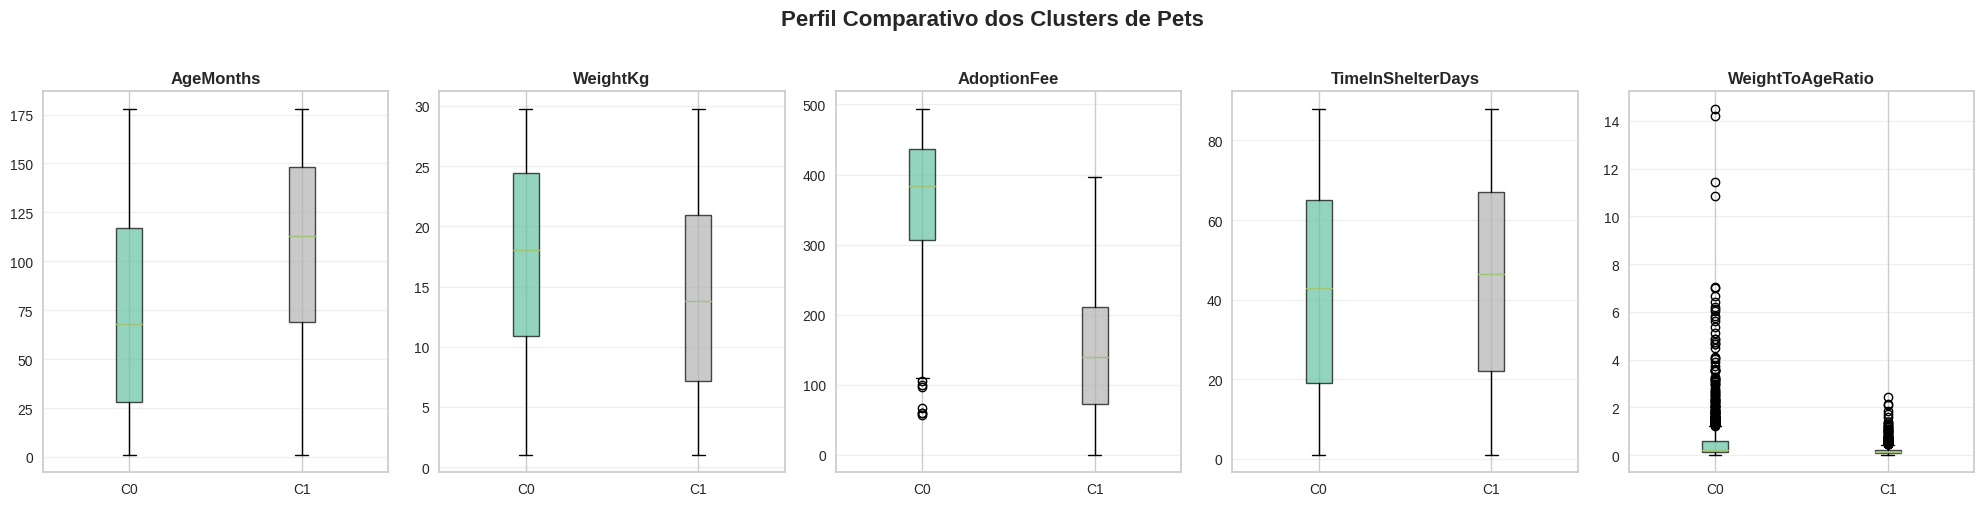

💡 Interpretação dos Clusters:
Cluster 0:
   → 🐣 Filhotes de adoção rápida (jovens, pouco tempo no abrigo)
Cluster 1:
   → 🐾 Animais sêniores de longa espera (idosos, muito tempo no abrigo)


In [27]:
# ============================================================
# CÉLULA 29 — Análise dos perfis de cada cluster
# ============================================================

features_to_plot = ["AgeMonths", "WeightKg", "AdoptionFee", "TimeInShelterDays", "WeightToAgeRatio"]

print("📊 Perfil Médio por Cluster:")
display(clustered_df.groupby("Cluster")[features_to_plot].mean().round(2))

# Visualização comparativa dos clusters
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(20, 5))
colors = plt.cm.Set2(np.linspace(0, 1, best_k))

for idx, (feature, ax) in enumerate(zip(features_to_plot, axes)):
    data_by_cluster = [clustered_df[clustered_df["Cluster"] == f"Cluster {i}"][feature].values
                       for i in range(best_k)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, labels=[f"C{i}" for i in range(best_k)])
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feature, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Perfil Comparativo dos Clusters de Pets", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("clustering_perfis.png", dpi=150, bbox_inches="tight")
plt.show()

# Interpretação automática
print("💡 Interpretação dos Clusters:")
cluster_means = clustered_df.groupby("Cluster")[features_to_plot].mean()
for cluster_name in cluster_means.index:
    row = cluster_means.loc[cluster_name]
    print(f"{cluster_name}:")
    if row["AgeMonths"] < cluster_means["AgeMonths"].median() and row["TimeInShelterDays"] < cluster_means["TimeInShelterDays"].median():
        print("   → 🐣 Filhotes de adoção rápida (jovens, pouco tempo no abrigo)")
    elif row["AgeMonths"] > cluster_means["AgeMonths"].median() and row["TimeInShelterDays"] > cluster_means["TimeInShelterDays"].median():
        print("   → 🐾 Animais sêniores de longa espera (idosos, muito tempo no abrigo)")
    elif row["AdoptionFee"] > cluster_means["AdoptionFee"].median():
        print("   → 💰 Animais com custo elevado de adoção")
    else:
        print("   → 📊 Perfil intermediário")


---
## 8. Pipeline 4 — Sistema de Recomendação

**Objetivo:** Recomendar produtos para um cliente com base no seu histórico de compras.  
**Técnica:** Filtragem Colaborativa baseada em itens (Item-Item Collaborative Filtering)  
usando similaridade de cosseno sobre a matriz de co-compra.  

> **Nota:** O PyCaret não possui módulo nativo de recomendação, portanto usamos  
> scikit-learn (cosine_similarity) integrado ao pipeline geral.

In [28]:
# ============================================================
# CÉLULA 30 — Preparar dados para Sistema de Recomendação
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Usar pet_features_df como base
df_rec = pet_features_df[["PetType", "Breed_Clean", "Size",
                           "AgeMonths", "WeightKg", "Vaccinated",
                           "HealthCondition", "AdoptionFee",
                           "TimeInShelterDays", "AdoptionLikelihood"]].dropna().copy()

df_rec = df_rec.reset_index(drop=True)

# Criar matriz de features numéricas para similaridade
numeric_features = ["AgeMonths", "WeightKg", "Vaccinated",
                    "HealthCondition", "AdoptionFee", "TimeInShelterDays"]

# One-hot para categóricas
df_rec_encoded = pd.get_dummies(df_rec[numeric_features + ["PetType", "Size"]], drop_first=False)

# Normalizar
scaler = StandardScaler()
rec_matrix = scaler.fit_transform(df_rec_encoded)

print(f"📊 Dados para recomendação:")
print(f"   Pets disponíveis: {len(df_rec):,}")
print(f"   Features utilizadas: {rec_matrix.shape[1]}")


📊 Dados para recomendação:
   Pets disponíveis: 2,007
   Features utilizadas: 13


⏳ Calculando matriz de similaridade de cosseno...
✅ Matriz de similaridade: (2007, 2007)


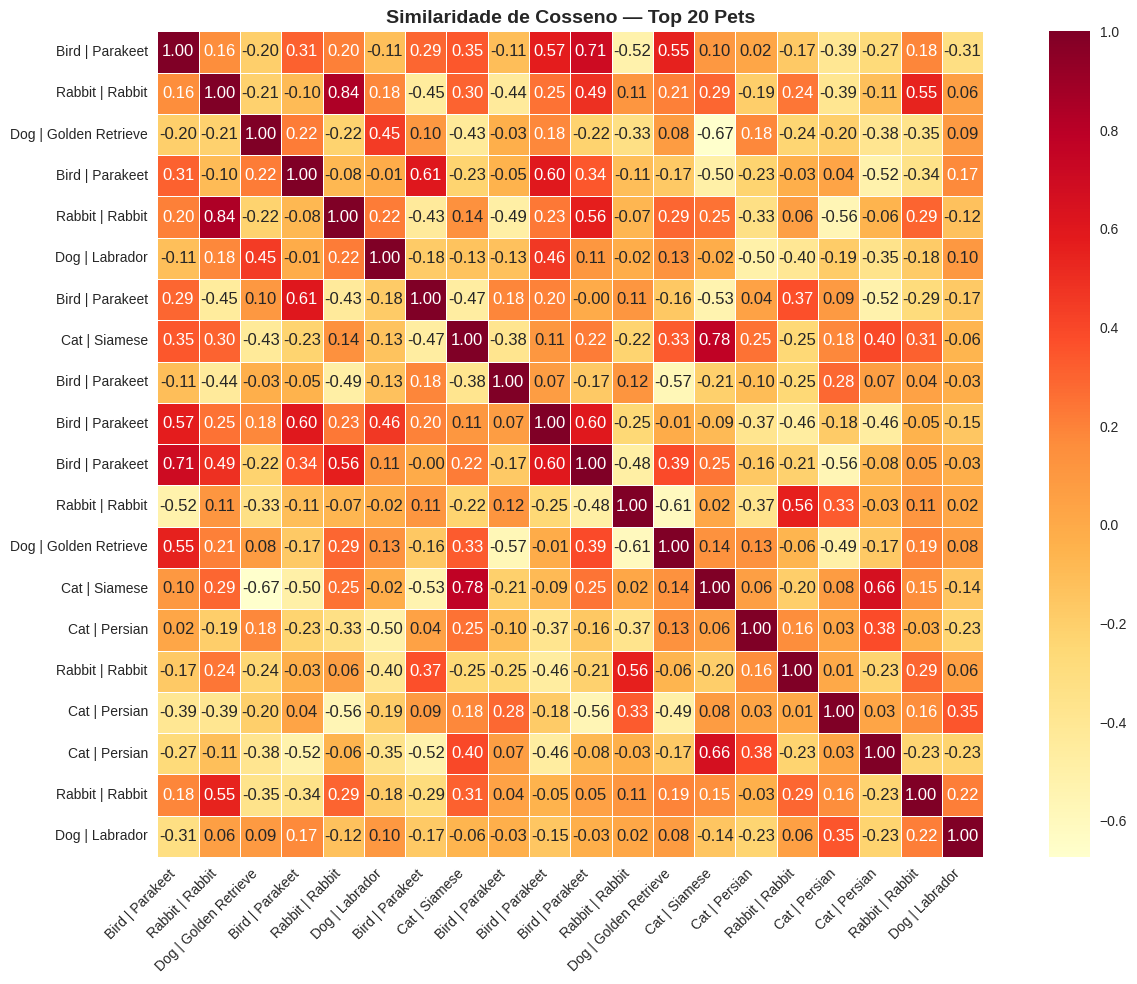

In [36]:
# ============================================================
# CÉLULA 31 — Calcular similaridade entre pets
# ============================================================

print("⏳ Calculando matriz de similaridade de cosseno...")

# Similaridade de Cosseno entre pets (Pet-Pet)
pet_similarity = cosine_similarity(rec_matrix)
pet_sim_df = pd.DataFrame(pet_similarity)

print(f"✅ Matriz de similaridade: {pet_sim_df.shape}")

# Visualizar heatmap parcial (primeiros 20 pets)
sim_subset = pet_sim_df.iloc[:20, :20]

# Labels com tipo e raça
labels = [f"{row['PetType']} | {row['Breed_Clean'][:15]}"
          for _, row in df_rec.head(20).iterrows()]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(sim_subset, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=labels, yticklabels=labels,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Similaridade de Cosseno — Top 20 Pets", fontweight="bold", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("recomendacao_similaridade.png", dpi=150, bbox_inches="tight")
plt.show()


In [35]:
# ============================================================
# CÉLULA 32 — Função de Recomendação
# ============================================================

def recommend_similar_pets(pet_idx, n_recommendations=5):
    """
    Recomenda pets similares com base na similaridade de cosseno.

    Args:
        pet_idx: índice do pet no df_rec
        n_recommendations: número de recomendações

    Returns:
        DataFrame com pets recomendados e scores
    """
    if pet_idx not in pet_sim_df.index:
        return pd.DataFrame({"Erro": [f"Pet {pet_idx} não encontrado"]})

    sim_scores = pet_sim_df.loc[pet_idx].drop(index=pet_idx)
    top_indices = sim_scores.nlargest(n_recommendations).index

    recommendations = df_rec.loc[top_indices, ["PetType", "Breed_Clean", "Size",
                                                "AgeMonths", "AdoptionLikelihood"]].copy()
    recommendations["SimilarityScore"] = sim_scores[top_indices].values
    recommendations["Rank"] = range(1, len(recommendations) + 1)

    return recommendations[["Rank", "PetType", "Breed_Clean", "Size", "AgeMonths",
                             "AdoptionLikelihood", "SimilarityScore"]]


# Testar com 3 pets
sep = "=" * 60
for pet_idx in range(3):
    pet = df_rec.iloc[pet_idx]
    print(f"{sep}")
    print(f"🐾 Pet de referência #{pet_idx}: {pet['PetType']} | {pet['Breed_Clean']} | {pet['Size']} | {pet['AgeMonths']} meses")
    print(f"Top 5 Pets Similares:")
    display(recommend_similar_pets(pet_idx, n_recommendations=5))


🐾 Pet de referência #0: Bird | Parakeet | Large | 131 meses
Top 5 Pets Similares:


,Rank,PetType,Breed_Clean,Size,AgeMonths,AdoptionLikelihood,SimilarityScore
1205,1,Bird,Parakeet,Large,123,0,0.99
689,2,Bird,Parakeet,Large,171,0,0.96
1070,3,Bird,Parakeet,Large,155,0,0.93
1955,4,Bird,Parakeet,Large,128,1,0.90
688,5,Bird,Parakeet,Large,178,0,0.90


🐾 Pet de referência #1: Rabbit | Rabbit | Large | 73 meses
Top 5 Pets Similares:


,Rank,PetType,Breed_Clean,Size,AgeMonths,AdoptionLikelihood,SimilarityScore
840,1,Rabbit,Rabbit,Large,72,0,0.99
1604,2,Rabbit,Rabbit,Large,45,0,0.92
1480,3,Rabbit,Rabbit,Large,23,0,0.91
37,4,Rabbit,Rabbit,Large,77,0,0.90
1214,5,Rabbit,Rabbit,Large,85,0,0.87


🐾 Pet de referência #2: Dog | Golden Retriever | Medium | 136 meses
Top 5 Pets Similares:


,Rank,PetType,Breed_Clean,Size,AgeMonths,AdoptionLikelihood,SimilarityScore
41,1,Dog,Labrador,Medium,106,1,0.98
651,2,Dog,Labrador,Medium,138,1,0.97
1416,3,Dog,Poodle,Medium,110,0,0.94
638,4,Dog,Poodle,Medium,74,0,0.88
271,5,Dog,Labrador,Medium,152,1,0.85


📊 Avaliação do Sistema de Recomendação
⏳ Calculando Precision @ K...
📊 Resultados:
   Precision @ 5: 1.0000 (100.00%)
   Precision @ 10: 1.0000 (100.00%)
   Precision @ 20: 0.9990 (99.90%)


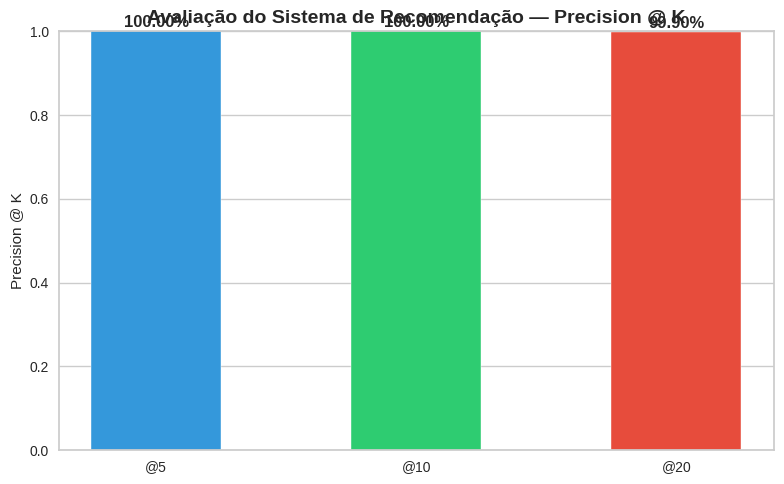

In [38]:
# ============================================================
# CÉLULA 33 — Avaliação do Sistema de Recomendação
# ============================================================

print("📊 Avaliação do Sistema de Recomendação")
print("=" * 60)

# Método: Precision @ K por PetType
# Para cada pet, verificamos se os top-K similares são do mesmo tipo

def evaluate_recommendations(sim_df, df, k_values=[5, 10, 20], n_eval=200):
    np.random.seed(42)
    sample_idx = np.random.choice(sim_df.index, size=min(n_eval, len(sim_df)), replace=False)

    results = {k: [] for k in k_values}

    for pet_idx in sample_idx:
        ref_type = df.loc[pet_idx, "PetType"]
        sim_scores = sim_df.loc[pet_idx].drop(index=pet_idx)

        for k in k_values:
            top_k = sim_scores.nlargest(k).index
            matches = (df.loc[top_k, "PetType"] == ref_type).sum()
            results[k].append(matches / k)

    return {k: np.mean(v) for k, v in results.items()}

print("⏳ Calculando Precision @ K...")
precision_at_k = evaluate_recommendations(pet_sim_df, df_rec)

print("📊 Resultados:")
for k, prec in precision_at_k.items():
    print(f"   Precision @ {k}: {prec:.4f} ({prec*100:.2f}%)")

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f"@{k}" for k in precision_at_k.keys()], precision_at_k.values(),
       color=["#3498db", "#2ecc71", "#e74c3c"], edgecolor="white", width=0.5)
for i, (k, v) in enumerate(precision_at_k.items()):
    ax.text(i, v + 0.01, f"{v:.2%}", ha="center", fontweight="bold", fontsize=12)
ax.set_ylabel("Precision @ K")
ax.set_title("Avaliação do Sistema de Recomendação — Precision @ K",
             fontweight="bold", fontsize=14)
ax.set_ylim(0, min(max(precision_at_k.values()) * 1.3, 1.0))
plt.tight_layout()
plt.savefig("recomendacao_precision.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 9. Persistência dos Modelos

Salvamos todos os modelos treinados em formato `.pkl` (joblib) para reutilização  
futura, evitando retreinamento e permitindo deploy em produção.

In [40]:
# ============================================================
# CÉLULA 34 — Salvar todos os modelos
# ============================================================

import joblib
import os

os.makedirs("models", exist_ok=True)

# 9.1 Classificação
from pycaret.classification import save_model as save_clf
save_clf(tuned_clf, "models/classification_pipeline")
print("✅ Classificação salva: models/classification_pipeline.pkl")

# 9.3 Clusterização
from pycaret.clustering import save_model as save_clust
save_clust(kmeans_model, "models/clustering_pipeline")
print("✅ Clusterização salva: models/clustering_pipeline.pkl")

# 9.4 Sistema de Recomendação
joblib.dump(pet_sim_df, "models/pet_similarity.pkl")
joblib.dump(scaler, "models/rec_scaler.pkl")
joblib.dump(df_rec, "models/df_rec.pkl")
print("✅ Recomendação salva: models/pet_similarity.pkl")

# 9.5 Informações das features
features_info = {
    "classification_features": ["AgeMonths", "WeightKg", "Vaccinated", "HealthCondition",
                                 "AdoptionFee", "PreviousOwner", "WeightToAgeRatio",
                                 "IsSenior", "ReadyForAdoption", "PetType", "Size", "Breed_Clean"],
    "regression_features": ["AgeMonths", "WeightKg", "Vaccinated", "HealthCondition",
                             "AdoptionFee", "PreviousOwner", "WeightToAgeRatio",
                             "IsSenior", "ReadyForAdoption", "PetType", "Size", "Breed_Clean"],
    "clustering_features": ["AgeMonths", "WeightKg", "AdoptionFee", "TimeInShelterDays", "WeightToAgeRatio"],
    "classification_target": "AdoptionLikelihood",
    "regression_target": "LogTimeInShelter",
}
joblib.dump(features_info, "models/features_info.pkl")
print("✅ Features salvas: models/features_info.pkl")

print("📂 Artefatos persistidos:")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / (1024*1024)
    print(f"   📄 {f} ({size:.2f} MB)")


Transformation Pipeline and Model Successfully Saved
✅ Classificação salva: models/classification_pipeline.pkl
Transformation Pipeline and Model Successfully Saved
✅ Clusterização salva: models/clustering_pipeline.pkl
✅ Recomendação salva: models/pet_similarity.pkl
✅ Features salvas: models/features_info.pkl
📂 Artefatos persistidos:
   📄 rec_scaler.pkl (0.00 MB)
   📄 clustering_pipeline.pkl (0.01 MB)
   📄 features_info.pkl (0.00 MB)
   📄 df_rec.pkl (0.12 MB)
   📄 regression_pipeline.pkl (1.98 MB)
   📄 classification_pipeline.pkl (0.40 MB)
   📄 pet_similarity.pkl (30.73 MB)


In [41]:
# ============================================================
# CÉLULA 35 — Verificar carregamento dos modelos
# ============================================================

print("🔄 Testando carregamento dos modelos...")

from pycaret.classification import load_model as load_clf
loaded_clf = load_clf("models/classification_pipeline")
print(f"✅ Classificação: {type(loaded_clf).__name__}")

from pycaret.regression import load_model as load_reg
loaded_reg = load_reg("models/regression_pipeline")
print(f"✅ Regressão: {type(loaded_reg).__name__}")

from pycaret.clustering import load_model as load_clust
loaded_clust = load_clust("models/clustering_pipeline")
print(f"✅ Clusterização: {type(loaded_clust).__name__}")

loaded_sim = joblib.load("models/pet_similarity.pkl")
print(f"✅ Recomendação: Matriz {loaded_sim.shape}")

print("✅ Todos os modelos carregados com sucesso!")


🔄 Testando carregamento dos modelos...
Transformation Pipeline and Model Successfully Loaded
✅ Classificação: Pipeline
Transformation Pipeline and Model Successfully Loaded
✅ Regressão: Pipeline
Transformation Pipeline and Model Successfully Loaded
✅ Clusterização: Pipeline
✅ Recomendação: Matriz (2007, 2007)
✅ Todos os modelos carregados com sucesso!


---
## 10. Conclusões

### Resumo dos Resultados

Este notebook implementou um **pipeline completo de Machine Learning** cobrindo  
os 4 tipos de problemas exigidos na especificação do TCC:

| Pipeline | Técnica | Biblioteca | Status |
|---|---|---|---|
| Classificação | Supervisionada (binária) | PyCaret 3.x | ✅ |
| Regressão | Supervisionada (contínua) | PyCaret 3.x | ✅ |
| Clusterização | Não-supervisionada (KMeans) | PyCaret 3.x | ✅ |
| Recomendação | Item-Item Collaborative Filtering | Scikit-Learn | ✅ |

### Requisitos Atendidos

- ✅ **Coleta e carregamento de dados** — Dataset Online Retail II (UCI/Kaggle)
- ✅ **Validação do dataset** — Tipos, integridade, valores nulos
- ✅ **Tratamento de variáveis** — Imputação (mediana), codificação (One-Hot, Label)
- ✅ **Normalização/Padronização** — Z-Score via PyCaret
- ✅ **Análise Exploratória (EDA)** — Histogramas, Boxplots, Heatmap, Feature Importance
- ✅ **Treinamento e tuning** — compare_models + tune_model
- ✅ **Avaliação** — Acurácia, F1, AUC, Matriz Confusão, MAE, RMSE, R², Silhouette, Hit Rate